In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib


#Load Dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()


In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}


In [8]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Compute metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {"RMSE": rmse, "R2 Score": r2}

results_df = pd.DataFrame(results).T
print(results_df)


                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732
Random Forest      0.544523  0.773731


In [9]:
param_grid = {"alpha": [0.1, 1.0, 10.0]}
ridge = GridSearchCV(Ridge(), param_grid, cv=5)
ridge.fit(X_train, y_train)
print("Best Ridge alpha:", ridge.best_params_)


Best Ridge alpha: {'alpha': 0.1}


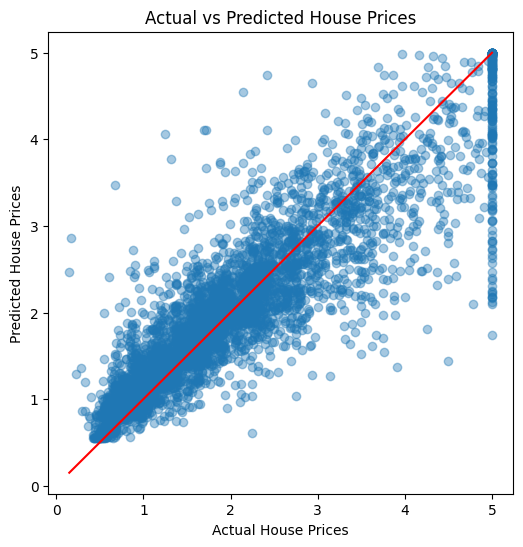

In [10]:
best_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.show()


In [11]:
joblib.dump(best_model, "best_house_price_model.pkl")


['best_house_price_model.pkl']